In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student-lifestyle-and-stress-dataset.csv to student-lifestyle-and-stress-dataset.csv


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [ ]:
df = pd.read_csv("student-lifestyle-and-stress-dataset.csv")


In [ ]:
print(df.columns)

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')


In [ ]:
print(df.head())

   Student_Type  Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
0             1     6.868702     1.711722            3.176942         NaN   
1             1     8.519088     3.251084            3.880787   93.978465   
2             0     4.498770     6.306885            2.936172   64.421253   
3             1     8.591223     2.384922            5.222832   81.868960   
4             0     5.329293     9.345179            7.815869   85.847982   

   Exam_Pressure  Family_Support  Month  Stress_Level  
0            8.0             7.0    2.0             1  
1            6.0             4.0    3.0             1  
2            7.0             1.0   12.0             1  
3            2.0             7.0    7.0             0  
4            5.0             6.0   10.0             1  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        25500 non-null  int64  
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 1.8 MB
None


In [ ]:
print(df.isnull().sum())

Student_Type             0
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64


In [ ]:
# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
print(df.isnull().sum())

Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64


In [ ]:
print("\nDUPLICATE VALUES")
print(df.duplicated().sum())



DUPLICATE VALUES
24


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.dtypes)

Student_Type            int64
Sleep_Hours           float64
Study_Hours           float64
Social_Media_Hours    float64
Attendance            float64
Exam_Pressure         float64
Family_Support        float64
Month                 float64
Stress_Level            int64
dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [ ]:
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20380, 8)
Testing data: (5096, 8)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)


In [ ]:

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8143642072213501

Confusion Matrix
[[3217  353]
 [ 593  933]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      3570
           1       0.73      0.61      0.66      1526

    accuracy                           0.81      5096
   macro avg       0.78      0.76      0.77      5096
weighted avg       0.81      0.81      0.81      5096



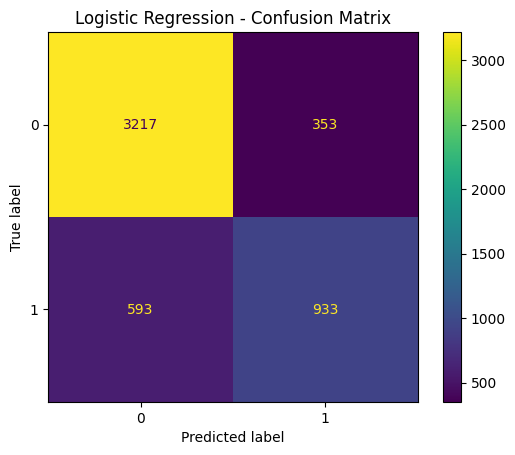

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

SVM Accuracy: 0.8143642072213501

Confusion Matrix
[[3217  353]
 [ 593  933]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      3570
           1       0.73      0.61      0.66      1526

    accuracy                           0.81      5096
   macro avg       0.78      0.76      0.77      5096
weighted avg       0.81      0.81      0.81      5096



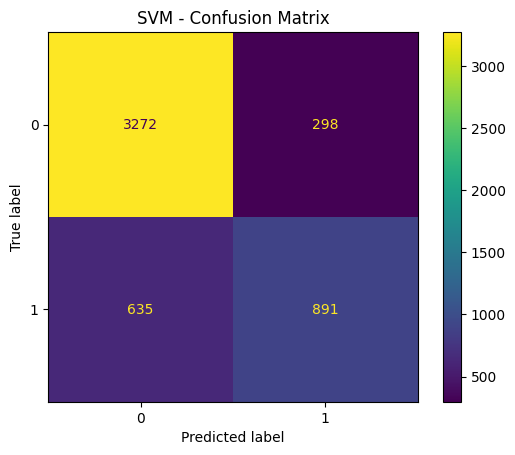

In [ ]:


print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix Graph
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test)
plt.title("SVM - Confusion Matrix")
plt.show()

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.7448979591836735

Confusion Matrix
[[2903  667]
 [ 633  893]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      3570
           1       0.57      0.59      0.58      1526

    accuracy                           0.74      5096
   macro avg       0.70      0.70      0.70      5096
weighted avg       0.75      0.74      0.75      5096



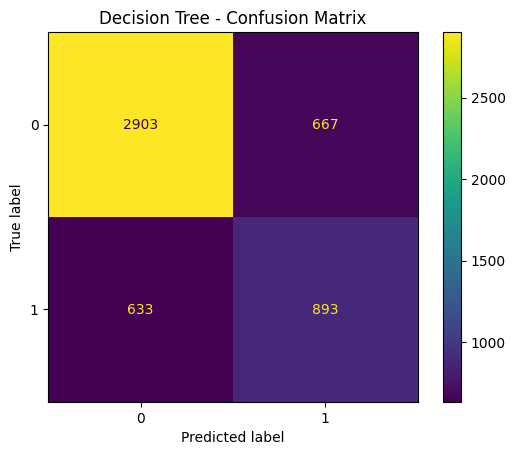

In [ ]:
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Random Forest Accuracy: 0.8122056514913658

Confusion Matrix
[[3233  337]
 [ 620  906]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      3570
           1       0.73      0.59      0.65      1526

    accuracy                           0.81      5096
   macro avg       0.78      0.75      0.76      5096
weighted avg       0.81      0.81      0.81      5096



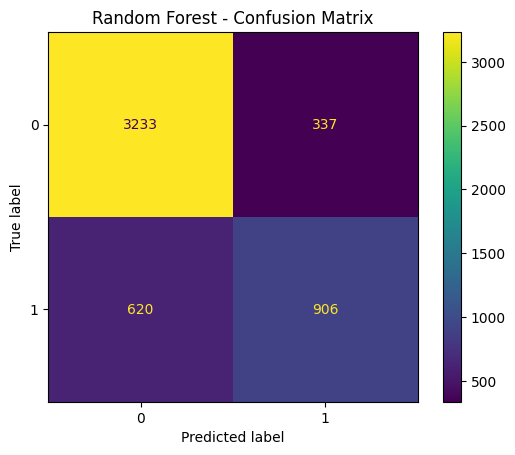

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()



KNN Accuracy: 0.7747252747252747

Confusion Matrix
[[3171  399]
 [ 749  777]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      3570
           1       0.66      0.51      0.58      1526

    accuracy                           0.77      5096
   macro avg       0.73      0.70      0.71      5096
weighted avg       0.76      0.77      0.77      5096



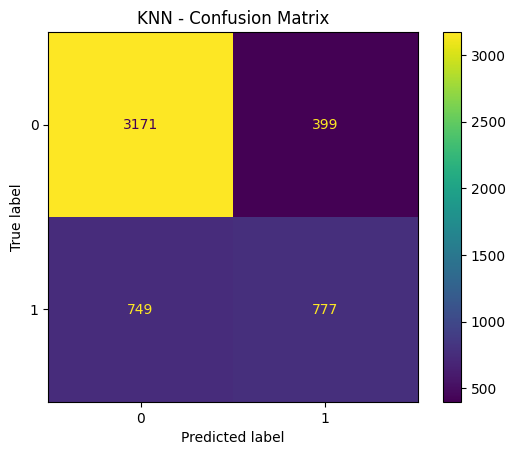

In [ ]:

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN - Confusion Matrix")
plt.show()

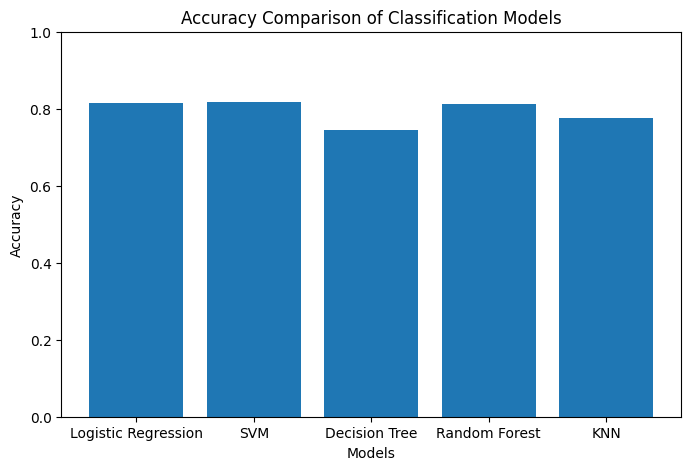

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM", "Decision Tree", "Random Forest", "KNN"]

accuracies = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    accuracy_score(y_test, rf.predict(X_test)),
    accuracy_score(y_test, knn.predict(X_test))
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.ylim(0, 1)
plt.show()

In [ ]:
best_accuracy = max(accuracies)
best_model = models[accuracies.index(best_accuracy)]

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)

Best Model: SVM
Best Accuracy: 0.8169152276295133


In [ ]:
print(X.columns)

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month'],
      dtype='object')


In [ ]:
new_data = [[1, 7, 5, 2, 90, 3, 4, 6]]

prediction = rf.predict(new_data)
print("Predicted Stress Level:", prediction)

Predicted Stress Level: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(rf, "stress_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!
